## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D) 

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들) 
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data import Dataset, random_split
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device 정보: {device}")

device 정보: cuda


torch.Size([28, 28])


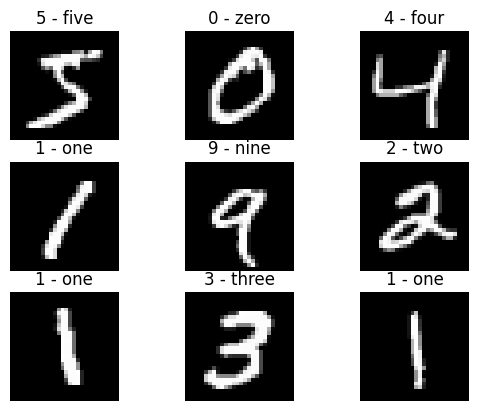

In [2]:
# 데이터셋 정의 -> MNIST
train_data = datasets.MNIST(
    './data/',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
)

test_data = datasets.MNIST(
    './data/',
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
)

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i], cmap='gray')
    plt.axis('off')
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

In [3]:
class CustomMNIST(Dataset):
    def __init__(self, root, train=True, download=False):
        self.base_dataset = datasets.MNIST(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.transform = transforms.Compose([
            transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)) if self.train else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, y = self.base_dataset[idx]
        x = self.transform(x)
        return x, y

## Modeling

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim, dropout_p=0.2):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # regularization
        self.dropout = nn.Dropout2d(p=dropout_p)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)
        
        return x

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()

        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16, dropout_p=0.1)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64, dropout_p=0.2)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128, dropout_p=0.3)

        self.fc1 = nn.Linear(in_features=256 * 3 * 3, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [6]:
# train/val split
val_ratio = 0.1
val_size = int(len(train_data) * val_ratio)
train_size = len(train_data) - val_size

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

# 데이터로더 정의
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=256, shuffle=False)

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout2d(p=0.1, inplace=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, strid

In [7]:
# Learning rate
lr = 1e-3

# Optimizer (weight_decay로 L2 regularization)
optim = Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# Early Stopping 설정
best_val_loss = float('inf')
patience = 5
patience_cnt = 0

# Train loop
for epoch in range(100):
    # train
    model.train()
    train_loss = 0.0
    num_train = 0

    for data, label in tqdm(train_loader):
        optim.zero_grad()

        preds = model(data.to(device))

        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

        bs = data.size(0)
        train_loss += loss.item() * bs
        num_train += bs

    train_loss /= num_train

    # validation
    model.eval()
    val_loss = 0.0
    num_val = 0
    val_corr = 0

    with torch.no_grad():
        for data, label in tqdm(val_loader):
            output = model(data.to(device))
            loss = nn.CrossEntropyLoss()(output, label.to(device))

            bs = data.size(0)
            val_loss += loss.item() * bs
            num_val += bs

            preds = output.data.max(1)[1]
            val_corr += preds.eq(label.to(device).data).sum().item()

    val_loss /= num_val
    val_acc = val_corr / num_val

    print(f"epoch{epoch+1} train_loss:{train_loss:.4f} | val_loss:{val_loss:.4f} | val_acc:{val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt = 0
        torch.save(model.state_dict(), "MNIST_best.pth")
    else:
        patience_cnt += 1
        if patience_cnt >= patience:
            print("Early stopping")
            break

100%|██████████| 24/24 [00:01<00:00, 15.70it/s]


epoch1 train_loss:0.7934 | val_loss:0.1262 | val_acc:0.9638


100%|██████████| 24/24 [00:01<00:00, 16.33it/s]


epoch2 train_loss:0.1714 | val_loss:0.0684 | val_acc:0.9813


100%|██████████| 24/24 [00:01<00:00, 16.46it/s]


...

epoch11 train_loss:0.0561 | val_loss:0.0394 | val_acc:0.9887


100%|██████████| 24/24 [00:01<00:00, 17.89it/s]


epoch12 train_loss:0.0571 | val_loss:0.0337 | val_acc:0.9902


100%|██████████| 24/24 [00:01<00:00, 16.71it/s]

epoch13 train_loss:0.0502 | val_loss:0.0352 | val_acc:0.9907
Early stopping


In [8]:
model.load_state_dict(torch.load("MNIST_best.pth", map_location=device))

model.eval()
num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

print(f"Test Accuracy:{num_corr/len(test_data):.4f}")

100%|██████████| 40/40 [00:01<00:00, 21.98it/s]

Test Accuracy:0.9945


데이터셋을 MNIST로 설정하고, 학습 안정화 및 일반화를 위해 데이터 증강, 정규화, BatchNorm, Dropout, He 초기화, Adam + weight_decay(L2 regularization), Early Stopping을 적용했다.

결과적으로 초반 수렴이 매우 빨랐고, 8epoch에서 val_loss가 최저로 가장 좋은 일반화 성능을 보였다. 이후, train_loss는 계속 줄었지만 val_loss가 다시 올라가며 개선이 정체되어 early stopping이 과적합을 막고 불필요한 학습을 줄였다. 최종적으로 Test Accuracy 0.9945로 매우 높은 성능을 얻었고, 적용한 규제 및 정규화 기법들이 빠른 수렴과 안정적인 일반화에 기여한 것으로 볼 수 있다.